In [1]:
!pip install pandas_datareader
!pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
# to read stock data from yahoo

from pandas_datareader.data import DataReader  #to read data directly online
import yfinance as yf
from pandas_datareader import data as pdr

from datetime import datetime


# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

#from last  year till now 
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)


for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)
    
company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name
    
df = pd.concat(company_list, axis=0)
df.sample(10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,company_name,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,GOOG,GOOG,GOOG,GOOG,...,MSFT,MSFT,MSFT,MSFT,MSFT,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,,,,,,,,,,,,,,,,
2025-06-20,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,209.690002,214.889999,208.270004,214.679993,75350700.0
2025-12-19,273.414185,274.343308,269.647689,271.895586,144632000.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-07,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,188.710007,190.990005,185.009995,185.559998,43948600.0
2025-11-06,269.256775,272.879874,267.380377,267.380377,51204000.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-02,NaN,NaN,NaN,NaN,NaN,GOOGLE,294.459991,295.899994,287.570007,288.989990,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-20,NaN,NaN,NaN,NaN,NaN,GOOGLE,321.933197,327.859015,320.664102,321.013831,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-23,NaN,NaN,NaN,NaN,NaN,MICROSOFT,NaN,NaN,NaN,NaN,...,447.579987,451.069724,446.317332,447.38116,16883500.0,NaN,NaN,NaN,NaN,NaN
2025-09-25,256.381317,256.680765,251.231145,252.728292,55202100.0,APPLE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


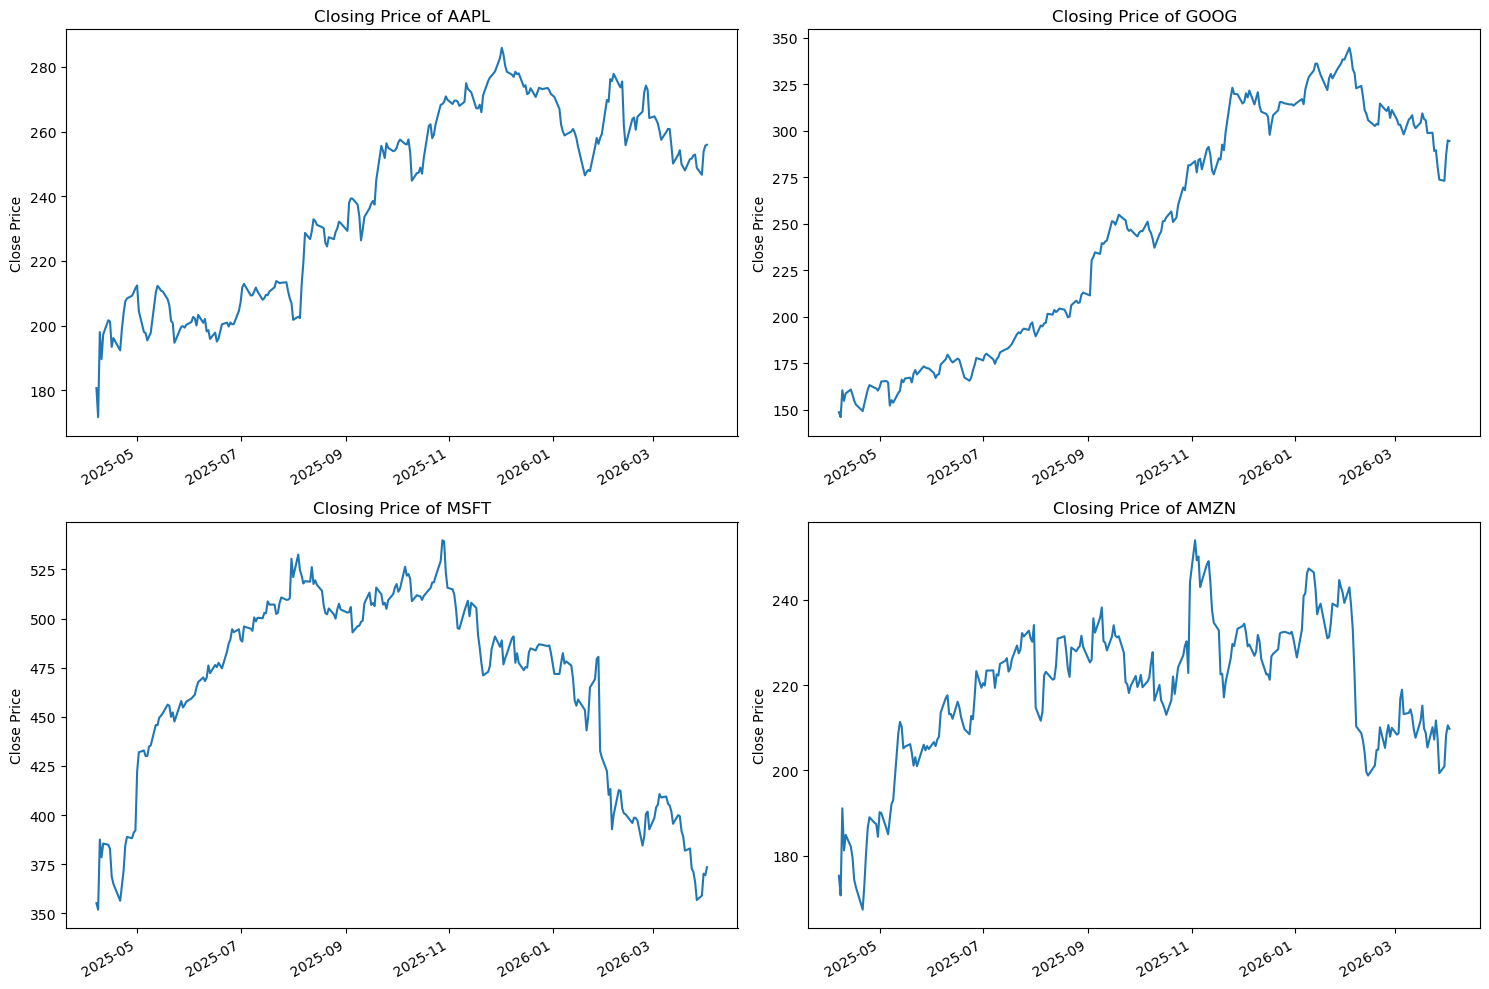

In [3]:
# the closing price : the last price at which the stock is traded during the regular trading day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, stock in enumerate(tech_list, 1):
    plt.subplot(2, 2, i)
    df[('Close', stock)].plot()  # استخدمنا ('Close', stock) بدل 'Adj Close'
    plt.ylabel('Close Price')
    plt.xlabel(None)
    plt.title(f"Closing Price of {stock}")

plt.tight_layout()
plt.show()

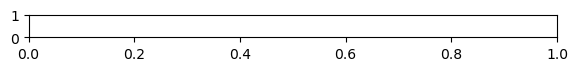

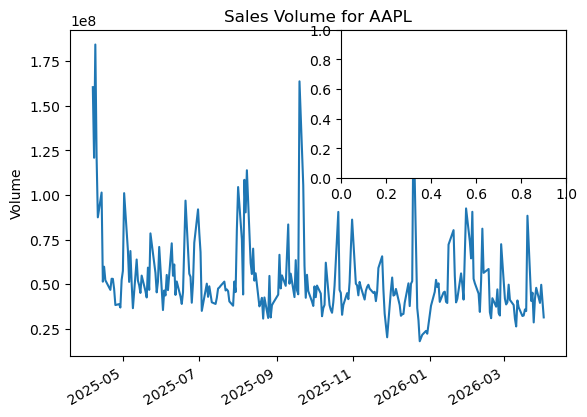

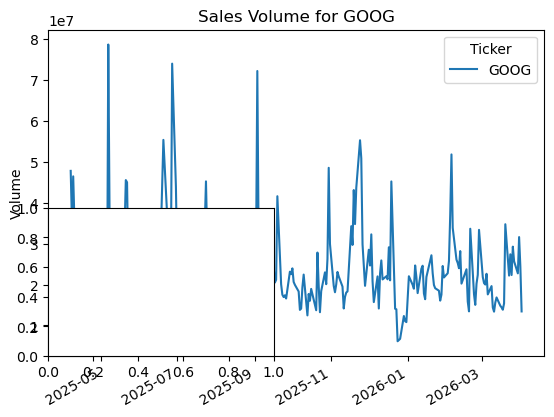

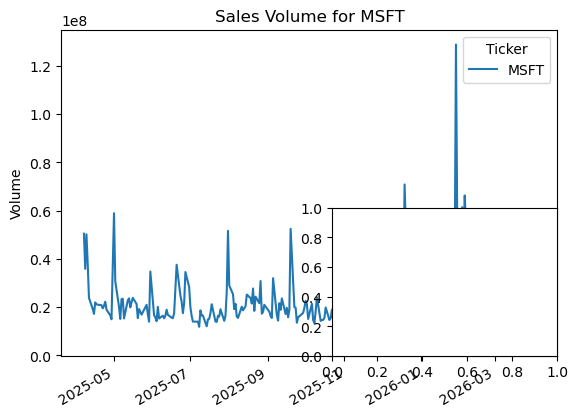

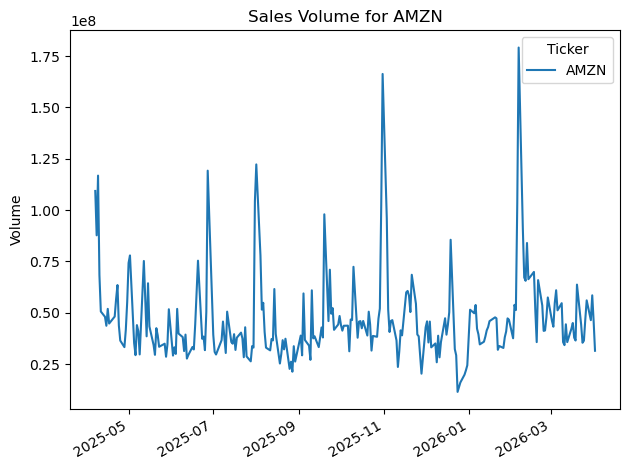

In [4]:
#the total volume of stock traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")
    
plt.tight_layout()

In [15]:

# Create features for each stock
all_data_scaled = []

for stock, com_name in zip(tech_list, company_name):
    # Get the stock dataframe
    stock_df = globals()[stock].copy()
    features = pd.DataFrame()
    features['Close'] = stock_df[('Close', stock)]
    features['Volume'] = stock_df[('Volume', stock)]
    features['Daily_Return'] = features['Close'].pct_change()
    features = features.dropna()
    
    # Scale the features
    scaler = MinMaxScaler()
    scaled_f = scaler.fit_transform(features)
    all_data_scaled.append(scaled_f)

def create_sequences(data_list, seq_length=120):
    X, y = [], []
    for data in data_list:
        for i in range(len(data) - seq_length - 1):
            X.append(data[i:i+seq_length])
            label = 1 if data[i+seq_length+1][0] > data[i+seq_length][0] else 0
            y.append(label)
    return np.array(X), np.array(y)

X, y = create_sequences(all_data_scaled)

split = int(0.8 * len(X))
X_train, X_test = torch.FloatTensor(X[:split]), torch.FloatTensor(X[split:])
y_train, y_test = torch.FloatTensor(y[:split]), torch.FloatTensor(y[split:])

In [20]:
from torch.utils.data import DataLoader, TensorDataset

# CNN&LSTM-Hybrid model definition
class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, input_size, hidden_size=256):
        super(CNN_LSTM_Classifier, self).__init__()
        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # LSTM: classifier
        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden_size, 
                            num_layers=2, batch_first=True, dropout=0.3)
    
        self.fc = nn.Linear(hidden_size, 1) 
        self.sigmoid = nn.Sigmoid()         

    def forward(self, x):
        x = x.permute(0, 2, 1)  # CNN expects (batch, features, seq_len)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)  # LSTM expects (batch, seq_len, features)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  
        return out

# Initialize model, loss function, and optimizer
model = CNN_LSTM_Classifier(input_size=3)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("Training started")
for epoch in range(60):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch+1) % 5== 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/60], Loss: {avg_loss:.4f}")

Training started
Epoch [5/60], Loss: 0.6930
Epoch [10/60], Loss: 0.6941
Epoch [15/60], Loss: 0.6925
Epoch [20/60], Loss: 0.6913
Epoch [25/60], Loss: 0.6861
Epoch [30/60], Loss: 0.6823
Epoch [35/60], Loss: 0.6746
Epoch [40/60], Loss: 0.6690
Epoch [45/60], Loss: 0.6607
Epoch [50/60], Loss: 0.6526
Epoch [55/60], Loss: 0.6605
Epoch [60/60], Loss: 0.6521


In [21]:
# Testing & Evaluation
model.eval()
with torch.no_grad():
    # Test set
    test_outputs = model(X_test).squeeze()
    test_preds = (torch.sigmoid(test_outputs) > 0.5).float()
    test_accuracy = (test_preds == y_test).float().mean()
    
    # Training set
    train_outputs = model(X_train).squeeze()
    train_preds = (torch.sigmoid(train_outputs) > 0.5).float()
    train_accuracy = (train_preds == y_train).float().mean()

print(f"Final Training Accuracy: {train_accuracy.item()*100:.2f}%")
print(f"Final Test Accuracy: {test_accuracy.item()*100:.2f}%")

Final Training Accuracy: 61.82%
Final Test Accuracy: 57.84%
